## Short Term Memory

In [20]:
from langgraph.graph import StateGraph, START, END, MessagesState # MessageState is same as ModelState defined in other files
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline, HuggingFaceEmbeddings, HuggingFaceEndpoint
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from dotenv import load_dotenv

from langchain_core.messages.utils import trim_messages, count_tokens_approximately

In [2]:
load_dotenv()
hf_llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3.1-8B-Instruct",
    task="conversational",
    max_new_tokens=120,
    temperature=0.7,
)
llm = ChatHuggingFace(llm=hf_llm)

Triming Messages to maintain Short Term Memory (STM)

In [3]:
MAX_TOKENS = 100

def call_model(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    
    current_token_count = count_tokens_approximately(messages)
    print(f"Current token count: {current_token_count}")
    
    trimmed_messages = trim_messages(
        messages=messages,
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS,
    )
    
    print(f"Trimmed messages token count: {count_tokens_approximately(trimmed_messages)}")
    response = llm.invoke(trimmed_messages)
    return {"messages": [response]}

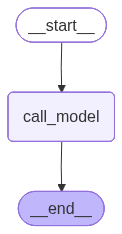

In [4]:
# Graph
graph = StateGraph(MessagesState)
graph.add_node("call_model", call_model)
graph.add_edge(START, "call_model")
graph.add_edge("call_model", END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [5]:
CONFIG = {
    "configurable":{
        "thread_id": "1234567890"
    }
}

In [6]:
initial_state = {
    "messages": [
        HumanMessage(content="Hi, I am Mohit, Can you tell me a joke?")
    ]
}
workflow.invoke(initial_state, config=CONFIG)

Current token count: 14
Trimmed messages token count: 14


{'messages': [HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a7e237eb-2635-42c7-86fc-61daa817248e'),
  AIMessage(content='Hello Mohit, I\'d be happy to share a joke with you. Here\'s one:\n\nA man walked into a library and asked the librarian, "Do you have any books on Pavlov\'s dogs and Schrödinger\'s cat?"\n\nThe librarian replied, "It rings a bell, but I\'m not sure if it\'s here or not."\n\nI hope you found that one amusing, Mohit! Do you want to hear another one?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 49, 'total_tokens': 141}, 'model_name': 'meta-llama/Meta-Llama-3.1-8B-Instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf0f8-a34e-7713-a1f9-b32a54ec4748-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 92, 'total_tokens': 141})]}

In [7]:
workflow.invoke(
    {
        "messages": [
            HumanMessage(content="Who am I?")
        ]
    },
    config=CONFIG
)

Current token count: 111
Trimmed messages token count: 97


{'messages': [HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a7e237eb-2635-42c7-86fc-61daa817248e'),
  AIMessage(content='Hello Mohit, I\'d be happy to share a joke with you. Here\'s one:\n\nA man walked into a library and asked the librarian, "Do you have any books on Pavlov\'s dogs and Schrödinger\'s cat?"\n\nThe librarian replied, "It rings a bell, but I\'m not sure if it\'s here or not."\n\nI hope you found that one amusing, Mohit! Do you want to hear another one?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 49, 'total_tokens': 141}, 'model_name': 'meta-llama/Meta-Llama-3.1-8B-Instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf0f8-a34e-7713-a1f9-b32a54ec4748-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 92, 'total_tokens': 141}),
  HumanMessage(content='Who am I?', add

In [8]:
workflow.invoke(
    {
        "messages": [
            HumanMessage(content="Tell a 80 words story about a dog and a cat.")
        ]
    },
    config=CONFIG
)

Current token count: 205
Trimmed messages token count: 94


{'messages': [HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a7e237eb-2635-42c7-86fc-61daa817248e'),
  AIMessage(content='Hello Mohit, I\'d be happy to share a joke with you. Here\'s one:\n\nA man walked into a library and asked the librarian, "Do you have any books on Pavlov\'s dogs and Schrödinger\'s cat?"\n\nThe librarian replied, "It rings a bell, but I\'m not sure if it\'s here or not."\n\nI hope you found that one amusing, Mohit! Do you want to hear another one?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 49, 'total_tokens': 141}, 'model_name': 'meta-llama/Meta-Llama-3.1-8B-Instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf0f8-a34e-7713-a1f9-b32a54ec4748-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 92, 'total_tokens': 141}),
  HumanMessage(content='Who am I?', add

In [ ]:
# Model forgets the name due to trimming messages
workflow.invoke(
    {
        "messages": [
            HumanMessage(content="What is my name?")
        ]
    },
    config=CONFIG
)

Current token count: 337
Trimmed messages token count: 8


{'messages': [HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a7e237eb-2635-42c7-86fc-61daa817248e'),
  AIMessage(content='Hello Mohit, I\'d be happy to share a joke with you. Here\'s one:\n\nA man walked into a library and asked the librarian, "Do you have any books on Pavlov\'s dogs and Schrödinger\'s cat?"\n\nThe librarian replied, "It rings a bell, but I\'m not sure if it\'s here or not."\n\nI hope you found that one amusing, Mohit! Do you want to hear another one?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 49, 'total_tokens': 141}, 'model_name': 'meta-llama/Meta-Llama-3.1-8B-Instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf0f8-a34e-7713-a1f9-b32a54ec4748-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 92, 'total_tokens': 141}),
  HumanMessage(content='Who am I?', add

Summarization to maintain STM

In [32]:
class SummaryState(TypedDict):
    summary: str
    messages: Annotated[list[BaseMessage], add_messages]

In [39]:
def summarize_conversation(state: SummaryState):
    summary = state["summary"]
    if summary:
        messages = [
            HumanMessage(content=f"Existing Summary: {summary}, Extend the summary using the following conversation: {state['messages']}")
        ]
    else:
        messages = [
            HumanMessage(content=f"Summarize the following conversation: {state['messages']}")
        ]
    
    print(f"Messages sent to LLM for summarization: {messages}")
        
    state["summary"] = llm.invoke(messages).content
    state["messages"] = state["messages"][-2:]  # Last 2 conversations are kept
    return state
        
def call_llm(state: SummaryState):
    messages = []
    summary = state["summary"]
    if summary:
        messages.append(HumanMessage(content=f"Existing Summary: {state['summary']}"))
        
    messages.extend(state["messages"])
    print(f"Messages sent to LLM for generation: {messages}")
    res = llm.invoke(messages)
    return {
        "messages": [res]
    }
    
def should_summarize(state: SummaryState):
    messages = state["messages"]
    token_count = count_tokens_approximately(messages)
    print(f"Token count before summarization: {token_count}")
    return token_count > MAX_TOKENS

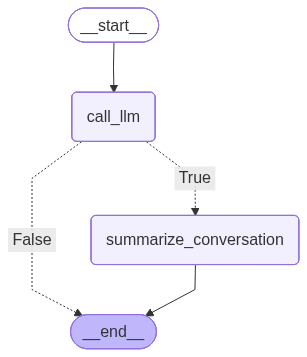

In [40]:
# Graph
summary_graph = StateGraph(SummaryState)
summary_graph.add_node("call_llm", call_llm)
summary_graph.add_node("summarize_conversation", summarize_conversation)

# edges
summary_graph.add_edge(START, "call_llm")
summary_graph.add_conditional_edges(
    "call_llm",
    should_summarize,
    {
        True: "summarize_conversation",
        False: END
    }
)

summary_workflow = summary_graph.compile(checkpointer=InMemorySaver())
summary_workflow

In [41]:
summary_workflow.invoke(
    SummaryState(
        messages=[
            HumanMessage(content="Hi, I am Mohit, Can you tell me a joke?")
        ],
        summary=""
    ),
    config=CONFIG
)

Messages sent to LLM for generation: [HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a2e38a4d-1be0-419e-92fb-ecf8d289c32f')]
Token count before summarization: 66


{'summary': '',
 'messages': [HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a2e38a4d-1be0-419e-92fb-ecf8d289c32f'),
  AIMessage(content="Hello Mohit, I'd be happy to share a joke with you. Here's one:\n\nWhat do you call a fake noodle?\n\n(wait for it...)\n\nAn impasta!\n\nHope that made you smile. Do you want to hear another one?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 49, 'total_tokens': 100}, 'model_name': 'meta-llama/Meta-Llama-3.1-8B-Instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf112-6a4b-7c83-a4d6-9af263b61950-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 51, 'total_tokens': 100})]}

In [42]:
summary_workflow.invoke(
    SummaryState(
        messages=[
            HumanMessage(content="Tell a 80 words story about a dog and a cat.")
        ],
    ),
    config=CONFIG
)

Messages sent to LLM for generation: [HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a2e38a4d-1be0-419e-92fb-ecf8d289c32f'), AIMessage(content="Hello Mohit, I'd be happy to share a joke with you. Here's one:\n\nWhat do you call a fake noodle?\n\n(wait for it...)\n\nAn impasta!\n\nHope that made you smile. Do you want to hear another one?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 49, 'total_tokens': 100}, 'model_name': 'meta-llama/Meta-Llama-3.1-8B-Instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf112-6a4b-7c83-a4d6-9af263b61950-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 51, 'total_tokens': 100}), HumanMessage(content='Tell a 80 words story about a dog and a cat.', additional_kwargs={}, response_metadata={}, id='7589bf58-81f6-41c1-932a-47528db43b18')]
Token count bef

{'summary': 'The conversation involves two users: Mohit and an AI assistant. Here\'s a summary of the conversation:\n\n1. Mohit starts the conversation by asking the AI assistant to share a joke. The AI assistant responds with a joke: "What do you call a fake noodle? An impasta!" Mohit doesn\'t respond to the joke.\n\n2. Mohit then asks the AI assistant to tell an 80-word story about a dog and a cat. The AI assistant responds with a heartwarming story about an unlikely friendship between a dog named Max and a cat named Whiskers. They',
 'messages': [HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a2e38a4d-1be0-419e-92fb-ecf8d289c32f'),
  AIMessage(content="Hello Mohit, I'd be happy to share a joke with you. Here's one:\n\nWhat do you call a fake noodle?\n\n(wait for it...)\n\nAn impasta!\n\nHope that made you smile. Do you want to hear another one?", additional_kwargs={}, response_metadata={'token_usage': {'completion_toke

In [43]:
# LLM remembers the name due to summarization
summary_workflow.invoke(
    SummaryState(
        messages=[
            HumanMessage(content="What is my name?")
        ],
    ),
    config=CONFIG
)

Messages sent to LLM for generation: [HumanMessage(content='Existing Summary: The conversation involves two users: Mohit and an AI assistant. Here\'s a summary of the conversation:\n\n1. Mohit starts the conversation by asking the AI assistant to share a joke. The AI assistant responds with a joke: "What do you call a fake noodle? An impasta!" Mohit doesn\'t respond to the joke.\n\n2. Mohit then asks the AI assistant to tell an 80-word story about a dog and a cat. The AI assistant responds with a heartwarming story about an unlikely friendship between a dog named Max and a cat named Whiskers. They', additional_kwargs={}, response_metadata={}), HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a2e38a4d-1be0-419e-92fb-ecf8d289c32f'), AIMessage(content="Hello Mohit, I'd be happy to share a joke with you. Here's one:\n\nWhat do you call a fake noodle?\n\n(wait for it...)\n\nAn impasta!\n\nHope that made you smile. Do you want to

{'summary': 'Extended Summary: \n\nThe conversation between Mohit and the AI assistant continues with Mohit asking a new question: "What is my name?" The AI assistant responds by saying "Your name is Mohit."',
 'messages': [HumanMessage(content='Hi, I am Mohit, Can you tell me a joke?', additional_kwargs={}, response_metadata={}, id='a2e38a4d-1be0-419e-92fb-ecf8d289c32f'),
  AIMessage(content="Hello Mohit, I'd be happy to share a joke with you. Here's one:\n\nWhat do you call a fake noodle?\n\n(wait for it...)\n\nAn impasta!\n\nHope that made you smile. Do you want to hear another one?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 49, 'total_tokens': 100}, 'model_name': 'meta-llama/Meta-Llama-3.1-8B-Instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf112-6a4b-7c83-a4d6-9af263b61950-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 51, 'total_